<a href="https://colab.research.google.com/github/JMMV314/ANE2_procesamiento/blob/main/Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks, peak_widths

In [13]:
class DigitalSignalProcessing:
    def __init__(self, file_path=None, f_start=None, f_stop=None, gain_dBi=0, bins=128):
        """
        DSP pipeline:
        1) Load CSV (from file_path or upload)
        2) Convert PSD to dBm/Hz
        3) Apply gain correction (if range provided)
        4) Estimate noise floor
        5) Detect peaks by threshold crossing (noise floor + 0.5 dB)
        6) Auto-generate all plots
        """
        self.file_path = file_path
        self.f_start = f_start
        self.f_stop = f_stop
        self.gain_dBi = gain_dBi
        self.bins = bins
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.peaks_df = None

        # --- Load CSV (upload if not provided)
        if self.file_path is None:
            print("📂 No file path provided — please upload your CSV file.")
            uploaded = files.upload()
            self.file_path = list(uploaded.keys())[0]
            print(f"✅ File '{self.file_path}' uploaded successfully.")

        print(f"\n⚙️ Initializing DSP pipeline for file: {self.file_path}")
        self._load_csv()
        self._convert_to_dBm_per_Hz()

        if self.f_start is not None and self.f_stop is not None:
            self._apply_gain_correction()
            self._estimate_noise_floor()
            self._detect_peaks_threshold(self.gain_dBi)
            print(f"✅ Processing completed.\nNoise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz\n")
            # Auto plots
            self.plot_comparison("Original vs Gain-Corrected PSD")
            self.plot_with_noise("Gain-Corrected PSD with Noise Floor")
            self.plot_detected_peaks("Detected Peaks over PSD")
        else:
            print("⚠️ No frequency range provided; skipping gain correction and noise estimation.")

    # ---------------------------------------------------------------
    # 1) Load CSV
    # ---------------------------------------------------------------
    def _load_csv(self):
        self.df = pd.read_csv(self.file_path)
        required_cols = ['Frecuencia (Hz)', 'PSD']
        if not all(col in self.df.columns for col in required_cols):
            raise ValueError("CSV must contain 'Frecuencia (Hz)' and 'PSD' columns.")
        self.df = self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'})
        self.df = self.df.dropna().drop_duplicates(subset=['freq_Hz'])
        self.df = self.df.sort_values(by='freq_Hz').reset_index(drop=True)
        print(f"📁 File '{self.file_path}' loaded successfully ({len(self.df)} samples).")

    # ---------------------------------------------------------------
    # 2) Convert PSD to dBm/Hz
    # ---------------------------------------------------------------
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz']
        if psd.mean() < 0:
            print("Detected PSD in dB scale → converting to linear first.")
            psd_linear = 10 ** (psd / 10.0)
        else:
            psd_linear = psd
        self.df['psd_WHz'] = psd_linear /50
        self.df['psd_WHz'] = np.maximum(psd_linear / 50, 1e-18) ##
        self.df['psd_dBmHz'] = 10 * np.log10(self.df['psd_WHz']) + 30
        print("✅ PSD converted to dBm/Hz.")

    # ---------------------------------------------------------------
    # 3) Apply gain correction
    # ---------------------------------------------------------------
    def _apply_gain_correction(self):
        psd_corr = self.df['psd_dBmHz'].copy()
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        psd_corr[mask] = psd_corr[mask] - self.gain_dBi
        self.df['psd_corr_dBmHz'] = psd_corr
        print(f"✅ Applied gain correction of {self.gain_dBi} dBi "
              f"between {self.f_start/1e6:.2f} MHz and {self.f_stop/1e6:.2f} MHz.")

    # ---------------------------------------------------------------
    # 4) Estimate noise floor
    # ---------------------------------------------------------------
    def _estimate_noise_floor(self):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Run _apply_gain_correction() first.")
        x = self.df['psd_corr_dBmHz'].to_numpy()
        clip_level = np.percentile(x, 80)
        x_clip = x[x <= clip_level]
        counts, edges = np.histogram(x_clip, bins=self.bins)
        imax = np.argmax(counts)
        mode_lo, mode_hi = edges[imax], edges[imax + 1]
        mode_center = 0.5 * (mode_lo + mode_hi)
        mask_ref = (x_clip >= mode_center - 3.0) & (x_clip <= mode_center + 3.0)
        noise_floor = float(np.mean(x_clip[mask_ref])) if mask_ref.any() else float(mode_center)
        self.noise_floor_dBmHz_ = noise_floor
        print(f"📉 Estimated noise floor: {noise_floor:.2f} dBm/Hz")

    # ---------------------------------------------------------------
    # 5) Detect peaks by threshold crossing
    # ---------------------------------------------------------------
    def _detect_peaks_threshold(self, delta_dB=0.4):
        """Detect peaks based on threshold crossing: noise floor + delta_dB."""
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated.")
        y = self.df['psd_corr_dBmHz'].to_numpy()
        f = self.df['freq_Hz'].to_numpy()
        threshold = self.noise_floor_dBmHz_ + delta_dB

        peaks = []
        in_peak = False
        start_idx = None

        for i in range(len(y)):
            if not in_peak and y[i] > threshold:
                in_peak = True
                start_idx = i
            elif in_peak and y[i] <= threshold:
                end_idx = i
                segment = y[start_idx:end_idx]
                seg_freq = f[start_idx:end_idx]
                max_idx = np.argmax(segment)
                f0 = seg_freq[max_idx]
                a0 = segment[max_idx]
                bw = seg_freq[-1] - seg_freq[0]
                peaks.append((f0, a0, bw))
                in_peak = False

        if in_peak:
          segment = y[start_idx:]
          seg_freq = f[start_idx:]
          max_idx = np.argmax(segment)
          f0 = seg_freq[max_idx]
          a0 = segment[max_idx]
          bw = seg_freq[-1] - seg_freq[0]
          peaks.append((f0, a0, bw))


        self.peaks_df = pd.DataFrame(peaks, columns=['f_center_Hz', 'amplitude_dBmHz', 'bandwidth_Hz'])
        if len(self.peaks_df) == 0:
            print("⚠️ No peaks detected above threshold.")
            return

        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz'] / 1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz'] / 1e3

        print(f"\n🔍 Detected {len(self.peaks_df)} peaks by threshold crossing "
              f"(>{threshold:.2f} dBm/Hz)\n")
        print("📡 Detected peaks and bandwidths:")
        print("──────────────────────────────────────────────────────────────")
        for _, row in self.peaks_df.iterrows():
            print(f"• f₀ = {row['f_center_MHz']:.3f} MHz | "
                  f"A = {row['amplitude_dBmHz']:.2f} dBm/Hz | "
                  f"BW = {row['bandwidth_kHz']:.1f} kHz")
        print("──────────────────────────────────────────────────────────────\n")

    # ---------------------------------------------------------------
    # 6) Plot original vs corrected PSD
    # ---------------------------------------------------------------
    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Gain correction not applied.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original PSD', linewidth=1.3)
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.3, linestyle='--')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title if title else "Original vs Gain-Corrected PSD")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # 7) Plot PSD + noise floor
    # ---------------------------------------------------------------
    def plot_with_noise(self, title=None):
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated yet.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', color='steelblue', linewidth=1.4)
        plt.axhline(self.noise_floor_dBmHz_, color='red', linestyle='--',
                    label=f"Noise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz", linewidth=1.3)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title if title else "Gain-Corrected PSD with Noise Floor")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------------
    # 8) Plot detected peaks
    # ---------------------------------------------------------------
    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df) == 0:
            print("⚠️ No peaks detected yet.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.2)
        plt.scatter(self.peaks_df['f_center_Hz'], self.peaks_df['amplitude_dBmHz'],
                    color='orange', label='Detected peaks')
        for _, row in self.peaks_df.iterrows():
            bw = row['bandwidth_Hz'] / 2
            plt.axvline(row['f_center_Hz'] - bw, color='gray', linestyle=':', alpha=0.5)
            plt.axvline(row['f_center_Hz'] + bw, color='gray', linestyle=':', alpha=0.5)
        plt.axhline(self.noise_floor_dBmHz_ + 0, color='green', linestyle='--', linewidth=1.2,
                    label=f"Threshold = noise floor ({self.noise_floor_dBmHz_ + 0.3:.2f})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title if title else "Detected Peaks and Bandwidths")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()


📂 No file path provided — please upload your CSV file.


Saving n0.csv to n0 (5).csv
✅ File 'n0 (5).csv' uploaded successfully.

⚙️ Initializing DSP pipeline for file: n0 (5).csv
📁 File 'n0 (5).csv' loaded successfully (4096 samples).
Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
✅ Applied gain correction of 0.5 dBi between -12.00 MHz and 10.00 MHz.
📉 Estimated noise floor: -66.43 dBm/Hz

🔍 Detected 42 peaks by threshold crossing (>-65.93 dBm/Hz)

📡 Detected peaks and bandwidths:
──────────────────────────────────────────────────────────────
• f₀ = -9.390 MHz | A = -64.43 dBm/Hz | BW = 141.6 kHz
• f₀ = -8.726 MHz | A = -65.86 dBm/Hz | BW = 4.9 kHz
• f₀ = -8.638 MHz | A = -64.96 dBm/Hz | BW = 180.7 kHz
• f₀ = -8.301 MHz | A = -62.88 dBm/Hz | BW = 73.2 kHz
• f₀ = -7.681 MHz | A = -65.92 dBm/Hz | BW = 0.0 kHz
• f₀ = -7.393 MHz | A = -65.53 dBm/Hz | BW = 97.7 kHz
• f₀ = -6.626 MHz | A = -64.73 dBm/Hz | BW = 136.7 kHz
• f₀ = -6.318 MHz | A = -62.17 dBm/Hz | BW = 92.8 kHz
• f₀ = -5.718 MHz | A = -65.89 dBm/Hz | 

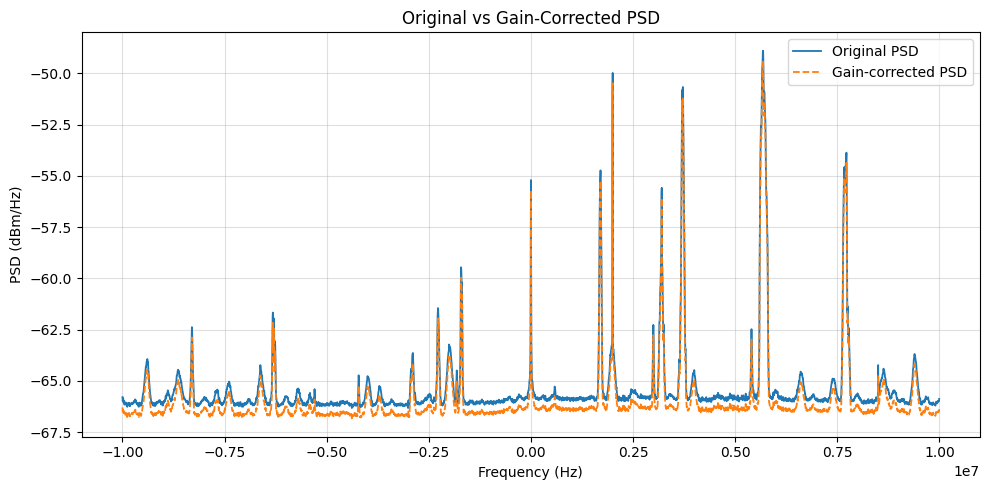

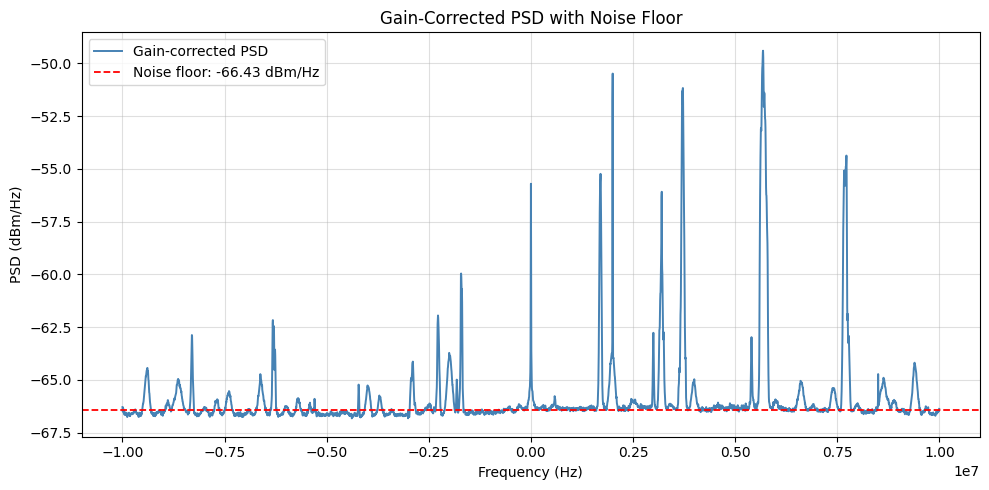

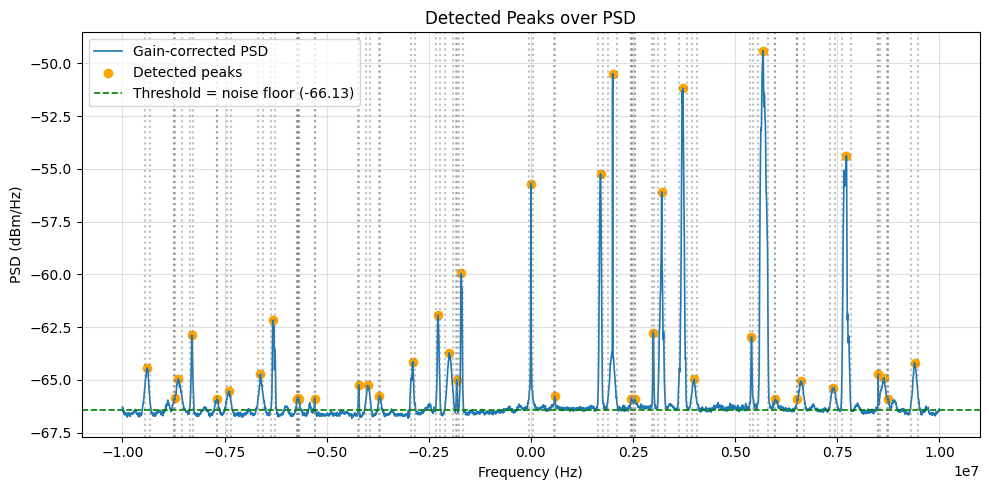

In [14]:
dsp = DigitalSignalProcessing(
    file_path=None,
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=0.5
)

#Versión JM

In [ ]:
class Adquisition:
    def __init__(self, file_path=None, f_start=None, f_stop=None, gain_dBi=0, bins=128):
        """
        DSP pipeline:
        1) Load CSV (from file_path or upload)
        2) Convert PSD to dBm/Hz
        3) Apply gain correction (if range provided)
        4) Estimate noise floor
        5) Detect peaks by threshold crossing (noise floor + 0.5 dB)
        6) Auto-generate all plots
        """
        self.file_path = file_path
        self.f_start = f_start
        self.f_stop = f_stop
        self.gain_dBi = gain_dBi
        self.bins = bins
        self.df = None
        self.noise_floor_dBmHz_ = None
        self.peaks_df = None

        # --- Load CSV (upload if not provided)
        if self.file_path is None:
            print("📂 No file path provided — please upload your CSV file.")
            uploaded = files.upload()
            self.file_path = list(uploaded.keys())[0]
            print(f"✅ File '{self.file_path}' uploaded successfully.")

        print(f"\n⚙️ Initializing DSP pipeline for file: {self.file_path}")
        self._load_csv()
        self._convert_to_dBm_per_Hz()

        if self.f_start is not None and self.f_stop is not None:
            self._apply_gain_correction()
            # self._estimate_noise_floor()
            # self._detect_peaks_threshold()
            # print(f"✅ Processing completed.\nNoise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz\n")
            # self.plot_comparison("Original vs Gain-Corrected PSD")
            # self.plot_with_noise("Gain-Corrected PSD with Noise Floor")
            # self.plot_detected_peaks("Detected Peaks over PSD")
        else:
            print("⚠️ No frequency range provided; skipping gain correction.")

    # ---------------------------------------------------------------
    # 1) Load CSV
    # ---------------------------------------------------------------
    def _load_csv(self):
        self.df = pd.read_csv(self.file_path)
        required_cols = ['Frecuencia (Hz)', 'PSD']
        if not all(col in self.df.columns for col in required_cols):
            raise ValueError("CSV must contain 'Frecuencia (Hz)' and 'PSD' columns.")
        self.df = self.df.rename(columns={'Frecuencia (Hz)': 'freq_Hz', 'PSD': 'psd_V2Hz'})
        self.df = self.df.dropna().drop_duplicates(subset=['freq_Hz'])
        self.df = self.df.sort_values(by='freq_Hz').reset_index(drop=True)
        print(f"📁 File '{self.file_path}' loaded successfully ({len(self.df)} samples).")

    # ---------------------------------------------------------------
    # 2) Convert PSD to dBm/Hz
    # ---------------------------------------------------------------
    def _convert_to_dBm_per_Hz(self):
        psd = self.df['psd_V2Hz']
        if psd.mean() < 0:
            print("Detected PSD in dB scale → converting to linear first.")
            psd_linear = 10 ** (psd / 10.0)
        else:
            psd_linear = psd

        # Convert V²/Hz → W/Hz (assuming 50 Ω system)
        self.df['psd_WHz'] = psd_linear / 50.0
        self.df['psd_dBmHz'] = 10 * np.log10(self.df['psd_WHz']) + 30
        print("✅ PSD converted to dBm/Hz.")

    # ---------------------------------------------------------------
    # 3) Apply gain correction
    # ---------------------------------------------------------------
    def _apply_gain_correction(self):
        psd_corr = self.df['psd_dBmHz'].copy()
        mask = (self.df['freq_Hz'] >= self.f_start) & (self.df['freq_Hz'] <= self.f_stop)
        psd_corr[mask] = psd_corr[mask] - self.gain_dBi
        self.df['psd_corr_dBmHz'] = psd_corr
        print(f"✅ Applied gain correction of {self.gain_dBi} dBi "
              f"between {self.f_start/1e6:.2f} MHz and {self.f_stop/1e6:.2f} MHz.")

    # ---------------------------------------------------------------
    # 4) Estimate noise floor
    # ---------------------------------------------------------------
    def _estimate_noise_floor(self):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Run _apply_gain_correction() first.")
        x = self.df['psd_corr_dBmHz'].to_numpy()
        clip_level = np.percentile(x, 80)
        x_clip = x[x <= clip_level]
        counts, edges = np.histogram(x_clip, bins=self.bins)
        imax = np.argmax(counts)
        mode_lo, mode_hi = edges[imax], edges[imax + 1]
        mode_center = 0.5 * (mode_lo + mode_hi)
        mask_ref = (x_clip >= mode_center - 3.0) & (x_clip <= mode_center + 3.0)
        noise_floor = float(np.mean(x_clip[mask_ref])) if mask_ref.any() else float(mode_center)
        self.noise_floor_dBmHz_ = noise_floor
        print(f"📉 Estimated noise floor: {noise_floor:.2f} dBm/Hz")
        return noise_floor

    # ---------------------------------------------------------------
    # 5) Detect peaks
    # ---------------------------------------------------------------
    def _detect_peaks_threshold(self, value=None, unit="dB", noise=None, bwWindow=None):
        """
        Detect peaks using either dB thresholding or percentage-based windowing.

        Parameters
        ----------
        value : float or None
            Threshold parameter:
              - If unit == "dB": difference (in dB) above the noise floor.
              - If unit == "percent": percentage value for window definition.
        unit : str
            Type of threshold. Must be either "dB" or "percent".
        noise : float or None
            Manually provided noise floor in dBm/Hz. If None, it will be estimated.
        """
        if unit not in ["dB", "percent"]:
            raise ValueError("unit must be either 'dB' or 'percent'.")

        y = self.df['psd_corr_dBmHz'].to_numpy()
        f = self.df['freq_Hz'].to_numpy()

        if noise is None:
            noise = self._estimate_noise_floor()
        self.noise_floor_dBmHz_ = noise

        # Case 1: Threshold defined in dB above noise floor
        if unit == "dB":
            delta_dB = value if value is not None else 0.4
            threshold = self.noise_floor_dBmHz_ + delta_dB
            print(f"📊 Threshold mode: dB-based | Noise floor = {self.noise_floor_dBmHz_:.2f} dBm/Hz | "
                  f"Δ = {delta_dB:.2f} dB → Threshold = {threshold:.2f} dBm/Hz")

        # Case 2: Threshold defined by percentage
        elif unit == "percent":
            if value is None:
                value = 99
            threshold = self.noise_floor_dBmHz_ + 0.4

            print(f"📊 Threshold mode: percentage-based | value = {value}% | Threshold = {threshold:.2f} dBm/Hz")

        # --- Peak detection
        peaks = []
        in_peak = False
        start_idx = None

        for i in range(len(y)):
            if not in_peak and y[i] > threshold:
                in_peak = True
                start_idx = i
            elif in_peak and y[i] <= threshold:
                end_idx = i
                segment = y[start_idx:end_idx]
                seg_freq = f[start_idx:end_idx]
                max_idx = np.argmax(segment)
                f0 = seg_freq[max_idx]
                a0 = segment[max_idx]
                bw = seg_freq[-1] - seg_freq[0]
                peaks.append((f0, a0, bw))
                in_peak = False

        # Results
        self.peaks_df = pd.DataFrame(peaks, columns=['f_center_Hz', 'amplitude_dBmHz', 'bandwidth_Hz'])
        if len(self.peaks_df) == 0:
            print("⚠️ No peaks detected above threshold.")
            return

        self.peaks_df['f_center_MHz'] = self.peaks_df['f_center_Hz'] / 1e6
        self.peaks_df['bandwidth_kHz'] = self.peaks_df['bandwidth_Hz'] / 1e3

        print(f"\n🔍 Detected {len(self.peaks_df)} peaks above threshold\n")
        for _, row in self.peaks_df.iterrows():
            print(f"• f₀ = {row['f_center_MHz']:.3f} MHz | "
                  f"A = {row['amplitude_dBmHz']:.2f} dBm/Hz | "
                  f"BW = {row['bandwidth_kHz']:.1f} kHz")
        print("──────────────────────────────────────────────────────────────\n")

    # ---------------------------------------------------------------
    # 6) Plot methods
    # ---------------------------------------------------------------
    def plot_comparison(self, title=None):
        if 'psd_corr_dBmHz' not in self.df.columns:
            raise ValueError("Gain correction not applied.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_dBmHz'], label='Original PSD', linewidth=1.3)
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.3, linestyle='--')
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Original vs Gain-Corrected PSD")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def plot_with_noise(self, title=None):
        if self.noise_floor_dBmHz_ is None:
            raise ValueError("Noise floor not estimated yet.")
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', color='steelblue', linewidth=1.4)
        plt.axhline(self.noise_floor_dBmHz_, color='red', linestyle='--',
                    label=f"Noise floor: {self.noise_floor_dBmHz_:.2f} dBm/Hz", linewidth=1.3)
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Gain-Corrected PSD with Noise Floor")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()

    def plot_detected_peaks(self, title=None):
        if self.peaks_df is None or len(self.peaks_df) == 0:
            print("⚠️ No peaks detected yet.")
            return
        plt.figure(figsize=(10, 5))
        plt.plot(self.df['freq_Hz'], self.df['psd_corr_dBmHz'], label='Gain-corrected PSD', linewidth=1.2)
        plt.scatter(self.peaks_df['f_center_Hz'], self.peaks_df['amplitude_dBmHz'],
                    color='orange', label='Detected peaks')
        for _, row in self.peaks_df.iterrows():
            bw = row['bandwidth_Hz'] / 2
            plt.axvline(row['f_center_Hz'] - bw, color='gray', linestyle=':', alpha=0.5)
            plt.axvline(row['f_center_Hz'] + bw, color='gray', linestyle=':', alpha=0.5)
        plt.axhline(self.noise_floor_dBmHz_ + 0.4, color='green', linestyle='--', linewidth=1.2,
                    label=f"Threshold = noise floor + 0.4 dB ({self.noise_floor_dBmHz_ + 0.3:.2f})")
        plt.xlabel("Frequency (Hz)")
        plt.ylabel("PSD (dBm/Hz)")
        plt.title(title or "Detected Peaks and Bandwidths")
        plt.legend()
        plt.grid(True, alpha=0.4)
        plt.tight_layout()
        plt.show()



In [ ]:
dsp = Adquisition(
    file_path=None,
    f_start=-12e6,
    f_stop=10e6,
    gain_dBi=3
)

📂 No file path provided — please upload your CSV file.


Saving n0.csv to n0.csv
✅ File 'n0.csv' uploaded successfully.

⚙️ Initializing DSP pipeline for file: n0.csv
📁 File 'n0.csv' loaded successfully (4096 samples).
Detected PSD in dB scale → converting to linear first.
✅ PSD converted to dBm/Hz.
✅ Applied gain correction of 3 dBi between -12.00 MHz and 10.00 MHz.
